# Data Challenge 11 — Evaluating MLR & Fixing Multicollinearity (HVFHV Trips)


**Format:** Instructor Guidance → You Do (Students) → We Share (Reflection)

**Goal:** Build an MLR, evaluate it with a **train–test split**, diagnose multicollinearity with **corr** and **VIF** on the **training set**, fix issues (drop/choose features), and report **test MAE/RMSE** + **coefficient interpretations**.

**Data:** July 1, 2023 - July 15, 2023 For Hire Vehicle Data in NYC

[July For Hire Vehicles Data](https://data.cityofnewyork.us/Transportation/2023-High-Volume-FHV-Trip-Data/u253-aew4/about_data)


## Instructor Guidance

**Hint: Use the Lecture Deck, Canvas Reading, and Docs to help you with the code**

Use this guide live; students implement below.

**Docs (quick links):**
- Train/Test Split — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- OLS — statsmodels: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html
- OLS Results (rsquared_adj, pvalues, resid, etc.): https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.html
- VIF — statsmodels: https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html
- Corr — pandas: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html

### Pseudocode Plan (Evaluation + Multicollinearity)
1) **Load CSV** → preview shape/columns; (optional) filter to **July**.
2) **Pick Y** (`base_passenger_fare`) and **candidate X’s** (e.g., `trip_miles`, `trip_time_minutes`, `tolls`, `tips` if present).
3) **Light prep** → derive `trip_time_minutes` from `trip_time` (seconds) if present; coerce only used cols to numeric; drop NA rows.
4) **Split** → `X_train, X_test, y_train, y_test` (80/20, fixed `random_state`).
5) **Diagnose on TRAIN**:
   - **Correlation matrix** (|r| > 0.7 = red flag).
   - **VIF** for each predictor (1–5 ok; >5–10+ = concerning).
6) **Fix** → drop/choose among highly correlated predictors (business logic).
7) **Fit on TRAIN only** → OLS with intercept.
8) **Predict on TEST** → compute **MAE/RMSE** (units of Y).
9) **Interpret** → unit-based coefficient sentences **holding others constant**; note any changes after fixing collinearity.
10) **Report** → table of (features kept, Adj R², MAE, RMSE) + 1-line stakeholder takeaway.


## You Do — Student Section
Work in pairs. Comment your choices briefly. Keep code simple—only coerce the columns you use.

### Step 0 — Setup & Imports

In [30]:
import pandas as pd, numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
pd.set_option('display.max_columns', None)

### Step 1 — Load CSV & Preview
- Point to your For Hire Vehicle Data 
- Print **shape** and **columns**.

**Hint: You may have to drop missing values and do a force coercion to make sure the variables stay numeric (other coding assignments may help)**

In [31]:
taxi = pd.read_csv('/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures_Kevin/Mod6/data/FHV_072023 copy.csv',
low_memory=False)


In [40]:
taxi['pickup_datetime'] = pd.to_datetime(taxi['pickup_datetime'], format="%m/%d/%Y %H:%M:%S %p")

# Keep only numeric and relevant columns
num_cols = ['trip_time_mins','trip_miles','trip_time', 'base_passenger_fare','airport_fee', 'tips', 'driver_pay']

for c in num_cols:
    taxi[c] = pd.to_numeric (
        taxi[c].astype(str).str.strip().str.replace(r'[^0-9.+\-eE]', '', regex=True),
        errors='coerce'
)
taxi['trip_time_mins'] = taxi['trip_time'] / 60

<Axes: xlabel='trip_time_mins', ylabel='base_passenger_fare'>

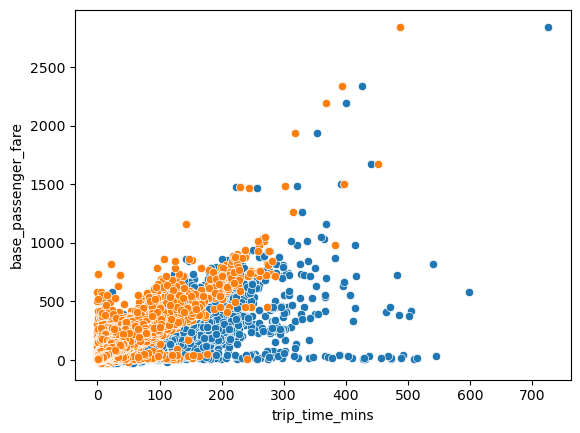

In [41]:
# Looking for extream outliers
import seaborn as sns
import matplotlib.pyplot as plt

# Create a basic scatterplot
sns.scatterplot(x="trip_time_mins", y="base_passenger_fare", data=taxi)

sns.scatterplot(x="trip_miles", y="base_passenger_fare", data=taxi)

In [42]:
def filter_outliers(df, filters):
    """
    Filter a DataFrame based on specified column conditions.

    Parameters:
        df (pd.DataFrame): The DataFrame to filter.
        filters (dict): Dictionary where keys are column names and values are tuples (min, max)
                        specifying the inclusive range of allowed values.

    Returns:
        pd.DataFrame: Filtered DataFrame.
    """
    df = df.dropna()
    for col, (min_val, max_val) in filters.items():
        df = df[(df[col] > min_val) & (df[col] <= max_val)]
    return df.copy()

# Define realistic ranges for trips
filters = {'trip_time_mins': (0, 5),  # e.g., max 5 hours
           'trip_miles': (0, 200)}      # max reasonable miles in NYC

# Apply filter on the full taxi dataset before splitting
taxi_filtered = filter_outliers(taxi, filters)

### Step 2 —  Choose Target **Y** and Candidate Predictors

- Suggested **Y**: `base_passenger_fare` (USD).
- Start with **distance** and **time**; optionally add **flags** if present.
- Derive `trip_time_minutes` from `trip_time` (seconds) if available.

In [43]:
candidate_cols = ['trip_time_mins', 'trip_miles']
X = taxi[candidate_cols].copy()
X = sm.add_constant(X).astype(float)
y = taxi['base_passenger_fare']

### Step 3 — Train–Test Split

- Use a fixed `random_state` for reproducibility.
- **All diagnostics below must be done on TRAIN only.**

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

### Step 4 — Diagnose Multicollinearity on **TRAIN** — Correlation Matrix
- Flag any |r| > 0.70 as a potential problem.


In [46]:
corr_matrix = X_train[candidate_cols].corr()
print("Correlation Matrix:\n", corr_matrix)


Correlation Matrix:
                 trip_time_mins  trip_miles
trip_time_mins          1.0000      0.8112
trip_miles              0.8112      1.0000


trip_miles & trip_time_mins has a |r|> 0.70 which means there's a high correlation between the two predictors.

### Step 5 — Diagnose Multicollinearity on **TRAIN** — VIF
- 1–5 normal; >5–10+ concerning.

In [47]:
vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print(vif_data)

          feature    VIF
0           const 3.2562
1  trip_time_mins 2.9246
2      trip_miles 2.9246


- VIF values < 5 which does not warrant multicollinearity concerns.
- Even though trip_time_mins and trip_miles are correlated (r = 0.81), the VIF shows it’s not high enough to warrant dropping either predictor.

### Step 6 — Fix High VIF (if needed)

- If two predictors are highly correlated, **drop/choose** using business logic (e.g., keep the more actionable one).
- Recompute VIF to confirm improvement.

It is not needed, VIF is less than 5

### Step 7 —  Fit on TRAIN Only, Predict on TEST, Evaluate MAE/RMSE

- Add intercept (`sm.add_constant`).
- Report **MAE/RMSE** in **units of Y**.
- Also capture **Adjusted R²** from the TRAIN fit summary to comment on fit (don’t use it alone for selection).


In [51]:
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

# Predict on TEST
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # works in all versions

print(f"Test MAE: ${mae:.2f}")
print(f"Test RMSE: ${rmse:.2f}")

                             OLS Regression Results                            
Dep. Variable:     base_passenger_fare   R-squared:                       0.843
Model:                             OLS   Adj. R-squared:                  0.843
Method:                  Least Squares   F-statistic:                 1.793e+07
Date:                 Thu, 06 Nov 2025   Prob (F-statistic):               0.00
Time:                         15:11:08   Log-Likelihood:            -2.3396e+07
No. Observations:              6659672   AIC:                         4.679e+07
Df Residuals:                  6659669   BIC:                         4.679e+07
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.3441      0.0

### Step 8 — Interpret Coefficients (Plain Language)

- **trip_miles:** Holding other variables constant, each additional **mile** is associated with an increase of approximately **$2.20** in **base fare**. The p-value is effectively 0, indicating this predictor is highly statistically significant and should be included in the model.  

- **trip_time_mins:** Holding other variables constant, each additional **minute** of trip time is associated with an increase of approximately **$0.49** in **base fare**. The p-value is effectively 0, confirming this predictor is highly statistically significant and supports its inclusion.  

- **Intercept (const):** The base fare, when both trip miles and trip time are zero, is approximately **$3.34**. The p-value is effectively 0, which is expected and indicates a meaningful starting point for fare predictions.  

**Summary:** Both predictors are statistically significant (p < 0.001) and have clear, interpretable effects on fare. Each extra mile increases fare by about $2.20, and each extra minute adds about $0.49, holding the other factor constant.  


## We Share — Reflection & Wrap‑Up

1) **Handling Multicollinearity:**  
When I checked the training data, trip time and trip miles were somewhat correlated (r = 0.81), which can sometimes cause multicollinearity. However, the VIF values for both predictors were below 3, indicating that they weren’t high enough to worry about. Because of this, I decided to keep both features in the model. The training fit was strong, with an Adjusted R² of 0.843, and the model performed well on unseen data, with a test MAE of $4.26 and RMSE of $8.21.

2) **Stakeholder Summary:**  
Looking at July trips, our model’s typical prediction error is about $4 per fare. Holding everything else constant, every extra mile adds roughly $2.20 to the fare, and each additional minute adds about $0.49. This gives a clear picture of how distance and trip time affect fares in practical terms.
